In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score

DATA_DIR = Path("../data/per_machine")

machine_ids = sorted(
    p.name.replace("_train.pkl", "")
    for p in DATA_DIR.glob("*_train.pkl")
)

print("Number of machines:", len(machine_ids))
print("Machines:", machine_ids)

X_train_all = {}
X_test_all = {}
y_test_all = {}

for machine in machine_ids:
    with open(DATA_DIR / f"{machine}_train.pkl", "rb") as f:
        X_train_all[machine] = pickle.load(f)

    with open(DATA_DIR / f"{machine}_test.pkl", "rb") as f:
        X_test_all[machine] = pickle.load(f)

    with open(DATA_DIR / f"{machine}_test_label.pkl", "rb") as f:
        y_test_all[machine] = np.asarray(pickle.load(f)).reshape(-1).astype(int)

Number of machines: 28
Machines: ['machine-1-1', 'machine-1-2', 'machine-1-3', 'machine-1-4', 'machine-1-5', 'machine-1-6', 'machine-1-7', 'machine-1-8', 'machine-2-1', 'machine-2-2', 'machine-2-3', 'machine-2-4', 'machine-2-5', 'machine-2-6', 'machine-2-7', 'machine-2-8', 'machine-2-9', 'machine-3-1', 'machine-3-10', 'machine-3-11', 'machine-3-2', 'machine-3-3', 'machine-3-4', 'machine-3-5', 'machine-3-6', 'machine-3-7', 'machine-3-8', 'machine-3-9']


In [2]:
rows = []

for machine in machine_ids:
    X_train = X_train_all[machine]
    X_test = X_test_all[machine]
    y_test = y_test_all[machine]

    train_df = pd.DataFrame(X_train)
    test_df = pd.DataFrame(X_test)

    row = {
        "machine": machine,
        "train_len": X_train.shape[0],
        "test_len": X_test.shape[0],
        "n_features": X_train.shape[1],
        "anomaly_points": int(y_test.sum()),
        "anomaly_rate": float(y_test.mean()),
        "constant_train_features": int((train_df.std() == 0).sum()),
        "constant_test_features": int((test_df.std() == 0).sum()),
        "train_min": float(np.min(X_train)),
        "train_max": float(np.max(X_train)),
        "test_min": float(np.min(X_test)),
        "test_max": float(np.max(X_test)),
    }
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("machine").sort_index()
summary_df

,train_len,test_len,n_features,anomaly_points,anomaly_rate,constant_train_features,constant_test_features,train_min,train_max,test_min,test_max
machine,,,,,,,,,,,
machine-1-1,28479,28479,38,2694,0.094596,8,6,0.0,1.0,0.0,1.0
machine-1-2,23694,23694,38,542,0.022875,5,5,0.0,1.0,0.0,1.0
machine-1-3,23702,23703,38,817,0.034468,4,4,0.0,1.0,0.0,1.0
machine-1-4,23706,23707,38,720,0.030371,4,4,0.0,1.0,0.0,1.0
machine-1-5,23705,23706,38,100,0.004218,8,8,0.0,1.0,0.0,1.0
machine-1-6,23688,23689,38,3708,0.156528,5,4,0.0,1.0,0.0,1.0
machine-1-7,23697,23697,38,2398,0.101194,4,4,0.0,1.0,0.0,1.0
machine-1-8,23698,23699,38,763,0.032195,8,8,0.0,1.0,0.0,1.0
machine-2-1,23693,23694,38,1170,0.049380,5,5,0.0,1.0,0.0,1.0


In [3]:
print("Total anomaly points across all machines:", int(summary_df["anomaly_points"].sum()))
print("Global anomaly rate:", summary_df["anomaly_points"].sum() / summary_df["test_len"].sum())

print("\nMachines with most anomaly points:")
summary_df.sort_values("anomaly_points", ascending=False).head(10)

Total anomaly points across all machines: 29444
Global anomaly rate: 0.041562914655148074

Machines with most anomaly points:


,train_len,test_len,n_features,anomaly_points,anomaly_rate,constant_train_features,constant_test_features,train_min,train_max,test_min,test_max
machine,,,,,,,,,,,
machine-1-6,23688,23689,38,3708,0.156528,5,4,0.0,1.0,0.0,1.0
machine-2-2,23699,23700,38,2833,0.119536,7,7,0.0,1.0,0.0,1.0
machine-1-1,28479,28479,38,2694,0.094596,8,6,0.0,1.0,0.0,1.0
machine-1-7,23697,23697,38,2398,0.101194,4,4,0.0,1.0,0.0,1.0
machine-2-9,28722,28722,38,1755,0.061103,8,8,0.0,1.0,0.0,1.0
machine-2-4,23689,23689,38,1694,0.071510,8,8,0.0,1.0,0.0,1.0
machine-3-8,28703,28704,38,1371,0.047763,8,7,0.0,1.0,0.0,1.0
machine-3-6,28726,28726,38,1194,0.041565,8,7,0.0,1.0,0.0,1.0
machine-2-1,23693,23694,38,1170,0.049380,5,5,0.0,1.0,0.0,1.0


In [4]:
def get_intervals(y):
    intervals = []
    in_interval = False
    start = None

    for i, val in enumerate(y):
        if val == 1 and not in_interval:
            start = i
            in_interval = True
        elif val == 0 and in_interval:
            intervals.append((start, i - 1))
            in_interval = False

    if in_interval:
        intervals.append((start, len(y) - 1))

    return intervals

In [5]:
interval_rows = []

for machine in machine_ids:
    y = y_test_all[machine]
    intervals = get_intervals(y)
    lengths = [end - start + 1 for start, end in intervals]

    interval_rows.append({
        "machine": machine,
        "n_intervals": len(intervals),
        "total_anomaly_points": int(y.sum()),
        "mean_interval_len": float(np.mean(lengths)) if lengths else 0.0,
        "median_interval_len": float(np.median(lengths)) if lengths else 0.0,
        "max_interval_len": int(np.max(lengths)) if lengths else 0,
        "min_interval_len": int(np.min(lengths)) if lengths else 0,
        "first_anomaly_idx": intervals[0][0] if intervals else None,
        "last_anomaly_idx": intervals[-1][1] if intervals else None,
    })

interval_df = pd.DataFrame(interval_rows).set_index("machine").sort_index()
interval_df

,n_intervals,total_anomaly_points,mean_interval_len,median_interval_len,max_interval_len,min_interval_len,first_anomaly_idx,last_anomaly_idx
machine,,,,,,,,
machine-1-1,8,2694,336.750000,433.0,721,2,15849,27555
machine-1-2,10,542,54.200000,53.5,156,3,4629,23114
machine-1-3,12,817,68.083333,46.0,225,3,392,23019
machine-1-4,12,720,60.000000,43.0,205,3,385,23220
machine-1-5,7,100,14.285714,11.0,31,4,10620,22076
machine-1-6,30,3708,123.600000,5.0,3161,3,246,22419
machine-1-7,13,2398,184.461538,26.0,1215,3,837,19589
machine-1-8,20,763,38.150000,4.0,371,3,710,22901
machine-2-1,13,1170,90.000000,26.0,452,8,6506,23294


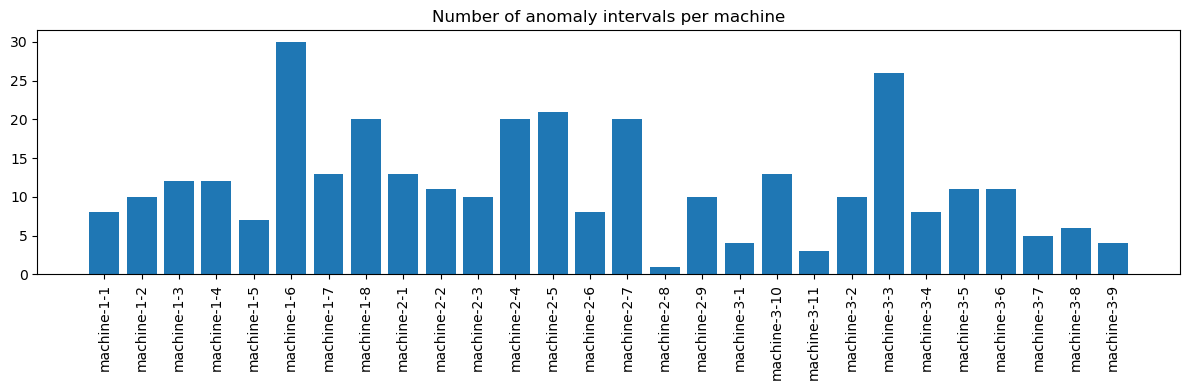

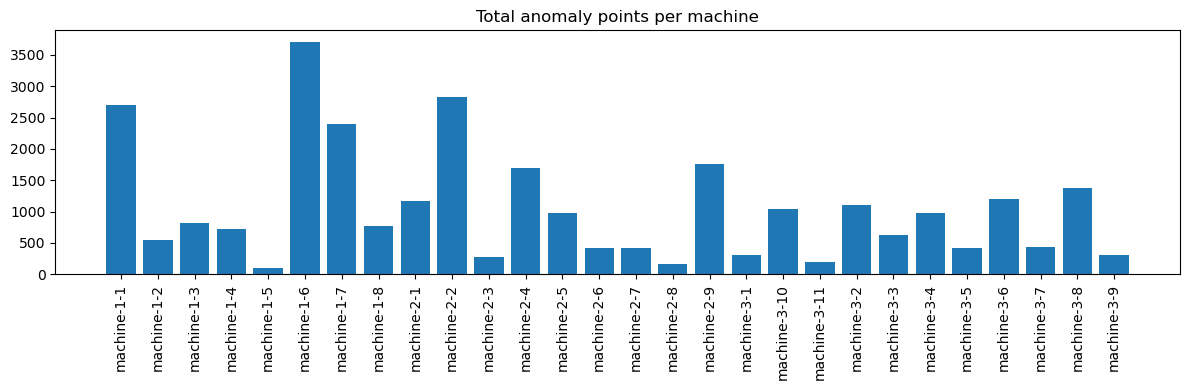

In [6]:
plt.figure(figsize=(12, 4))
plt.bar(interval_df.index, interval_df["n_intervals"])
plt.xticks(rotation=90)
plt.title("Number of anomaly intervals per machine")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.bar(interval_df.index, interval_df["total_anomaly_points"])
plt.xticks(rotation=90)
plt.title("Total anomaly points per machine")
plt.tight_layout()
plt.show()

In [7]:
max_len = max(len(y_test_all[machine]) for machine in machine_ids)

y_matrix = np.full((max_len, len(machine_ids)), np.nan)

for j, machine in enumerate(machine_ids):
    y = y_test_all[machine]
    y_matrix[:len(y), j] = y

print("Padded label matrix shape:", y_matrix.shape)

Padded label matrix shape: (28743, 28)


In [8]:
anomaly_count_per_time = np.nansum(y_matrix, axis=1)
valid_machine_count_per_time = np.sum(~np.isnan(y_matrix), axis=1)

print("Padded label matrix shape:", y_matrix.shape)
print("Time points with at least one anomaly:", int((anomaly_count_per_time > 0).sum()))
print("Time points where all available machines are anomalous:",
      int((anomaly_count_per_time == valid_machine_count_per_time).sum()))
print("Time points with all 28 machines present:",
      int((valid_machine_count_per_time == len(machine_ids)).sum()))

Padded label matrix shape: (28743, 28)
Time points with at least one anomaly: 13695
Time points where all available machines are anomalous: 0
Time points with all 28 machines present: 23687


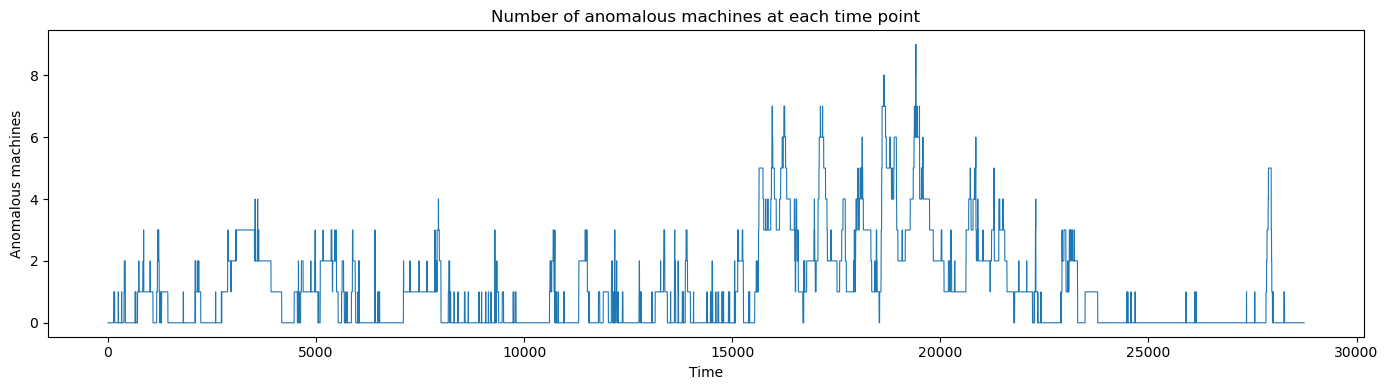

In [9]:
plt.figure(figsize=(14, 4))
plt.plot(anomaly_count_per_time, linewidth=0.8)
plt.title("Number of anomalous machines at each time point")
plt.xlabel("Time")
plt.ylabel("Anomalous machines")
plt.tight_layout()
plt.show()

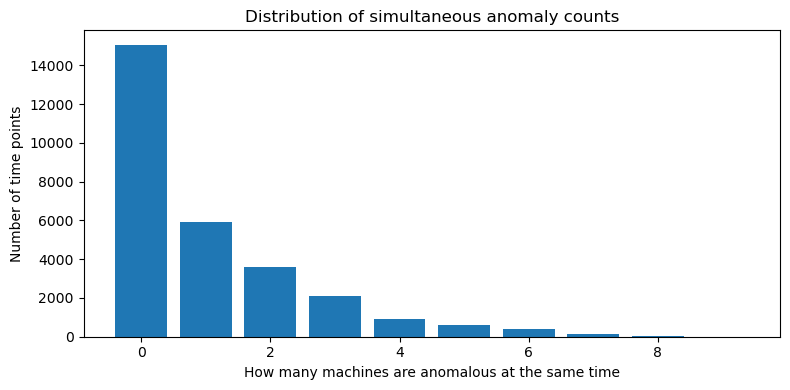

0.0    15048
1.0     5928
2.0     3616
3.0     2104
4.0      939
5.0      593
6.0      373
7.0      125
8.0       15
9.0        2
Name: count, dtype: int64

In [10]:
count_dist = pd.Series(anomaly_count_per_time).value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(count_dist.index, count_dist.values)
plt.title("Distribution of simultaneous anomaly counts")
plt.xlabel("How many machines are anomalous at the same time")
plt.ylabel("Number of time points")
plt.tight_layout()
plt.show()

count_dist

In [11]:
n_machines = len(machine_ids)

jaccard = np.full((n_machines, n_machines), np.nan)
cond_same_time = np.full((n_machines, n_machines), np.nan)

for i, machine_i in enumerate(machine_ids):
    for j, machine_j in enumerate(machine_ids):
        y_i_full = y_test_all[machine_i]
        y_j_full = y_test_all[machine_j]

        shared_len = min(len(y_i_full), len(y_j_full))
        y_i = y_i_full[:shared_len].astype(bool)
        y_j = y_j_full[:shared_len].astype(bool)

        intersection = np.sum(y_i & y_j)
        union = np.sum(y_i | y_j)

        jaccard[i, j] = intersection / union if union > 0 else np.nan
        cond_same_time[i, j] = intersection / np.sum(y_i) if np.sum(y_i) > 0 else np.nan

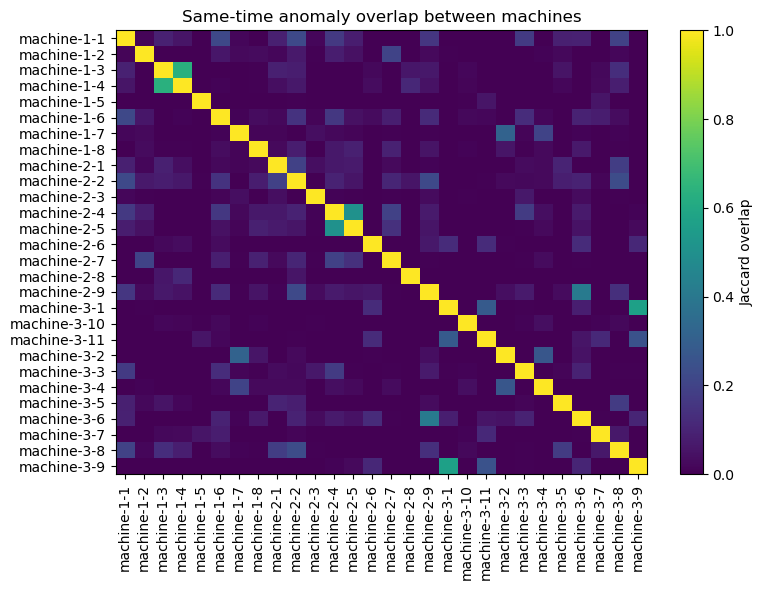

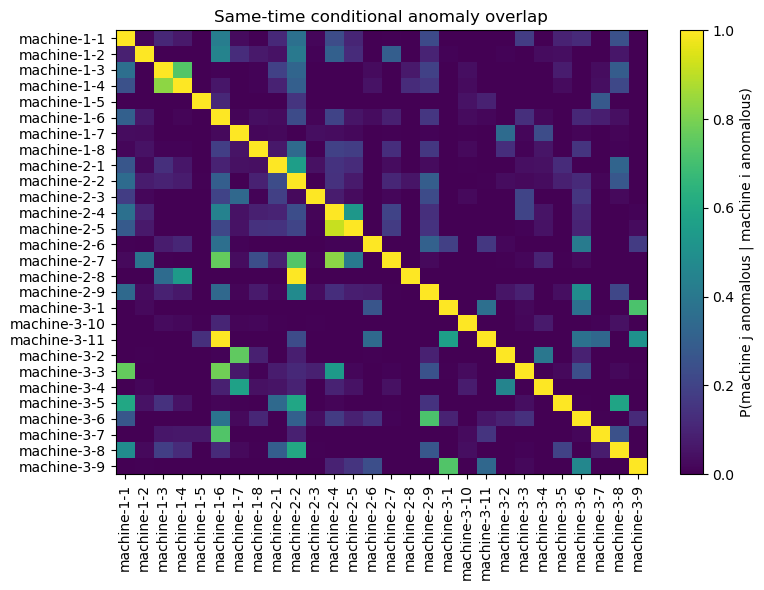

In [12]:
plt.figure(figsize=(8, 6))
plt.imshow(jaccard, aspect="auto")
plt.colorbar(label="Jaccard overlap")
plt.title("Same-time anomaly overlap between machines")
plt.xticks(range(n_machines), machine_ids, rotation=90)
plt.yticks(range(n_machines), machine_ids)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(cond_same_time, aspect="auto")
plt.colorbar(label="P(machine j anomalous | machine i anomalous)")
plt.title("Same-time conditional anomaly overlap")
plt.xticks(range(n_machines), machine_ids, rotation=90)
plt.yticks(range(n_machines), machine_ids)
plt.tight_layout()
plt.show()

In [13]:
same_time_pairs = []

for i, machine_i in enumerate(machine_ids):
    for j, machine_j in enumerate(machine_ids):
        if i == j:
            continue

        same_time_pairs.append({
            "source_machine": machine_i,
            "target_machine": machine_j,
            "jaccard": jaccard[i, j],
            "p_target_given_source_same_time": cond_same_time[i, j],
        })

same_time_pairs_df = pd.DataFrame(same_time_pairs)
same_time_pairs_df.sort_values("p_target_given_source_same_time", ascending=False).head(20)

,source_machine,target_machine,jaccard,p_target_given_source_same_time
414,machine-2-8,machine-2-2,0.056830,1.000000
518,machine-3-11,machine-1-6,0.017799,1.000000
335,machine-2-5,machine-2-4,0.503937,0.914286
83,machine-1-4,machine-1-3,0.635106,0.829167
389,machine-2-7,machine-2-4,0.194680,0.824940
572,machine-3-3,machine-1-6,0.128445,0.781646
383,machine-2-7,machine-1-6,0.083815,0.764988
567,machine-3-3,machine-1-1,0.169898,0.762658
546,machine-3-2,machine-1-7,0.313483,0.754734
387,machine-2-7,machine-2-2,0.103565,0.731415


In [14]:
train_mean_df = pd.DataFrame(
    {machine: X_train_all[machine].mean(axis=0) for machine in machine_ids}
).T

train_std_df = pd.DataFrame(
    {machine: X_train_all[machine].std(axis=0) for machine in machine_ids}
).T

feature_profile_df = pd.concat(
    [train_mean_df.add_prefix("mean_"), train_std_df.add_prefix("std_")],
    axis=1
)

profile_similarity = feature_profile_df.T.corr()

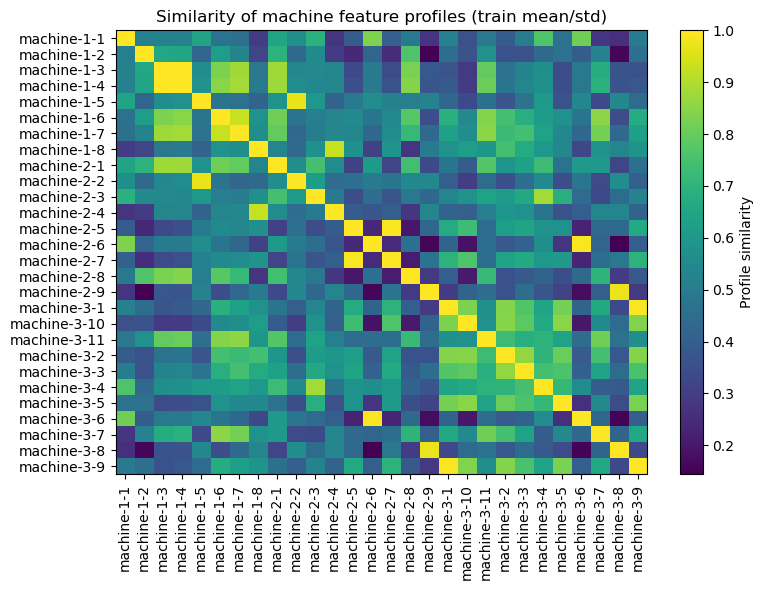

In [15]:
plt.figure(figsize=(8, 6))
plt.imshow(profile_similarity, aspect="auto")
plt.colorbar(label="Profile similarity")
plt.title("Similarity of machine feature profiles (train mean/std)")
plt.xticks(range(n_machines), machine_ids, rotation=90)
plt.yticks(range(n_machines), machine_ids)
plt.tight_layout()
plt.show()